In [ ]:
Content
1. Database Internals
2. Index Basics (Clustered and Non-Clustered)
    - 2.1 Seek vs Scan
    - 2.1.1 Types of Scan
    - 2.2 Index Working (Ordering)
    - 2.3 Row vs Column Oriented Databases
3. SQL query execution order
4. B Tree vs B+ Tree in Production System
5. Improving Efficiency

# 1. Database Internals

In [ ]:
# How tables and indexes are stored on disk

# Page
    - SQL Server uses a page-based storage architecture. Everything (tables, indexes, metadata) is stored in fixed-size units called pages.
    - The database does not read a single row, it reads a page or more in a single I/O operation.
    - Each page has a fix size (8KB in a postgress, and 16KB in MySQL)
    - Example: Assume each page holds 3 rows, with 1001 rows, it will have 1001/3 = ~333 pages
    - Each page contains:
        - A header
        - Rows (records)
        - A slot array (used to locate rows)

# Page and Extent: The Building Blocks
Page  : 8 KB           : The smallest I/O unit in SQL Server. All data (rows, index entries) is stored in pages.
Extent: 64 KB (8 pages): A unit of space allocation. SQL Server allocates extents to tables and indexes.

# I/O
    - It is a read/write request to the disk
    - We try to minimize this as much as possible.
    - An IO can fetch one or more page.
    - You can not read a single row, it always read the complete page.

# Heap
    - A data structure where table is stored with all its pages, one after another.
    - Reading a complete heap is expensive, that's why we use index that tells what pages of the heap we need to read.

# Index
    - A data structure (like B-tree), that has pointers to the heap.
    - Index can be done on one or more column.
    - Once you find a value in index, then you go to the heap to fetch more information.
    - Index tells you Exactly which page to fetch in the heap instead of taking the hit to scan every page in the heap.
    - The index is also stored as pages and cost IO to pull the entries of the index.

# Types of Tables
1. Heap Table (If a table has No clustered index)
	- Data is stored unsorted in pages.
	- SQL Server keeps a page chain to navigate rows.
	- No guarantee of order.
    - Use Case: When data is always accessed via non-clustered indexes or for staging tables.

2. Clustered Table (has a clustered index)
	- A table with a clustered index; rows are physically ordered by that index.
	- Pages are organized as a B+ Tree.
	- Leaf nodes store the actual table data.
    - Most common table type in production systems.
    - If a table has both indexes, then it stores the table via Clustered table.

In [ ]:
[Heap Table]
   |
   +-- Page 1 (8KB)
   |     ┌──────────── Page Header (96 bytes) ────────────┐
   |     │ - Page ID, Type, Free space, Row count, etc.   │
   |     └────────────────────────────────────────────────┘
   |     ┌──────────── Row 1 ────────────┐
   |     │ [Column1][Column2][Column3]  │
   |     └──────────────────────────────┘
   |     ┌──────────── Row 2 ────────────┐
   |     │ [Column1][Column2][Column3]  │
   |     └──────────────────────────────┘
   |     ┌──── Slot Array ────┐
   |     │ Ptr to Row 2      │ <-- Slot 0
   |     │ Ptr to Row 1      │ <-- Slot 1
   |     └───────────────────┘

   |
   +-- Page 2 (8KB)
   |     ┌──────────── Page Header ─────────────┐
   |     └──────────────────────────────────────┘
   |     ┌──────────── Row 3 ────────────┐
   |     └──────────────────────────────┘
   |     ┌──────────── Row 4 ────────────┐
   |     └──────────────────────────────┘
   |     ┌──── Slot Array ────┐
   |     └───────────────────┘

   |
   +-- More Pages...


| Component       | Description                                                               |
| --------------- | ------------------------------------------------------------------------- |
| **Heap Table**  | Table with no clustered index; data is in no particular order             |
| **Page**        | 8 KB unit of storage, contains rows and metadata                          |
| **Page Header** | Metadata about the page (type, free space, page ID)                       |
| **Row**         | Actual data for a record (includes fixed and variable-length fields)      |
| **Slot Array**  | Points to the physical location of rows in the page; helps in fast access |


In [ ]:
# Index Memory Representation
    - When an index is accessed: Index pages (nodes) are loaded into the buffer pool (memory)
    - Navigating from root → intermediate → leaf pages
    - leaf stores the page pointer of heap.
    - Each leaf node stores:
        - The indexed key
        - A row pointer (RID) or clustered key

In [ ]:
                 [Root Page]
 ┌─────────────────────────────────────────────┐
 │ Keys: [100 | 300]                           │
 │ Pointers: → Page A  → Page B  → Page C      │
 └─────────────────────────────────────────────┘

         ┌───────────────┬───────────────┐
         ▼               ▼               ▼

        [Page A]        [Page B]        [Page C]
 ┌────────────────┐ ┌────────────────┐ ┌────────────────┐
 │ Keys: [10, 50] │ │ Keys: [120, 180]│ │ Keys: [320, 400]│
 │ Pointers to leaf pages (or rows)   │
 └────────────────┘ └────────────────┘ └────────────────┘

          ▼                ▼                ▼

     [Leaf Page]      [Leaf Page]     [Leaf Page]
 ┌────────────────┐ ┌────────────────┐ ┌────────────────┐
 │ Key: 10 → RID  │ │ Key: 120 → RID │ │ Key: 320 → RID │
 │ Key: 50 → RID  │ │ Key: 180 → RID │ │ Key: 400 → RID │
 └────────────────┘ └────────────────┘ └────────────────┘



# 2. Index Basics (Clustered and Non-Clustered)

In [ ]:
An index is a data structure that improves the speed of data retrieval operations on a database table.
- Both type of index uses B Trees
- like queries %a% does not usually use an index

1. Clustered Index
	- A clustered index defines the physical order of data in the table.
	- Each table can have only one clustered index.
	- The leaf level of the clustered index tree stores the actual rows.
    - PRIMARY KEY will automatically create a clustered index on EmployeeId. The table’s rows are stored physically ordered by EmployeeId.
    -  Characteristics:
    	- Only one per table.
    	- Best / Fast for range queries and sorted results.
    	- Leaf nodes = actual data.
    	- Updating the clustered key is expensive — it may move the row.
    - If primary key is not required, better to avoid it as it increases the cost of Insert operation.
    - Example query:
                        CREATE TABLE Employees (
                            EmployeeId INT PRIMARY KEY,
                            Name VARCHAR(100),
                            Age INT
                        );

# Creating Clustered Index
Case 1:
    - If a table has a primary key, then you can not create a clustered index explicitely.
    - Example:
            CREATE TABLE Orders (
                OrderId INT PRIMARY KEY,       -- Creates a clustered index by default
                CustomerId INT,
                OrderDate DATE
            );

                    
Case 2: Create clustered index on multiple columns (called composite or compound clustered index)
    - Example:
                    CREATE CLUSTERED INDEX IX_TableName_Column1_Column2
                        ON TableName (Column1, Column2);
    - It means, Data will be physically sorted first by Column1, then by Column2 (if Column1 values are the same).
    - Ordering matters, ON (CustomerId, OrderDate) ≠ ON (OrderDate, CustomerId)
    - Query will use this only, if where clause has Column.

                      
Case 3: You want primary key to be non-clustered
    - PK is still unique, but stored in a non-clustered index.
    - You can now create a clustered index on other column(s). 
    - UseCase: 	If you’re building range-based or sorting queries (e.g., CustomerId, OrderDate), it might make more sense to use those as clustered index, and move PK to non-clustered.                                            
    - Example: 

                      CREATE TABLE Orders (
                        OrderId INT,
                        CustomerId INT,
                        OrderDate DATE,
                        CONSTRAINT PK_Orders PRIMARY KEY NONCLUSTERED (OrderId)
                    );
                    
                    CREATE CLUSTERED INDEX IX_Orders_CustomerId_OrderDate
                    ON Orders (CustomerId, OrderDate);

# If there is no Clustered index
 - Then it is a heap table - A table without clustered index
 - Rows are not sorted in any specific order
 - new rows are added wherever space is available (usually at the end of page)
 - Insert operation are generally faster as compared to clustered index table (which maintains order)                    

In [ ]:
2. Non-Clustered Index
    - A non-clustered index is a separate structure that maintains a copy of the indexed columns + a row locator.
	- The row locator depends on whether the base table is a heap or a clustered table.
    - Characteristics:
    	 - Can have multiple non-clustered indexes on a table.
    	 - Good for filtering, joins, or specific lookups.
    	 - Can be covering indexes (include extra columns).
    - Example:
            CREATE NONCLUSTERED INDEX IX_Employees_Age ON Employees(Age);
        - SQL Server creates a B+ tree for Age.
    	- Leaf nodes contain:
        	- Age (index key)
        	- Row locator: either
            	- RID (if heap), or
            	- Clustered key (if clustered index exists)

# Default 
- By default Index keyword creates a Non-clustered index.
    CREATE INDEX IX_MyTable_ABC ON MyTable (A, B, C);

In [ ]:
+-----------------------+--------------------------+-------------------------------+
| Feature               | Clustered Index          | Non-Clustered Index           |
+-----------------------+--------------------------+-------------------------------+
| Physical Row Order    | Yes (defines table order)| No (separate structure)       |
| Data Stored In        | Leaf nodes               | Separate from actual table    |
| Count per Table       | Only one                 | Many allowed                  |
| Leaf Node Contains    | Full row data            | Key + Row locator             |
| Fast For              | Range queries, sorting   | Point queries, filters        |
| Requires Row Lookup   | No                       | Yes (unless covering index)   |
+-----------------------+--------------------------+-------------------------------+

    CLUSTERED INDEX (Tree Structure - actual data stored in leaf)
--------------------------------------------------------------
        [Root Node]
           |
     +-----+------+
     |            |
[Intermediate] [Intermediate]
     |            |
 [Data Page 1]  [Data Page 2]   <-- actual data rows (ordered)

NON-CLUSTERED INDEX (Tree points to row location, not data itself)
-------------------------------------------------------------------
        [Root Node]
           |
     +-----+------+
     |            |
[Intermediate] [Intermediate]
     |            |
 [Leaf Node 1]  [Leaf Node 2]   <-- key + pointer to row (RID or clustered key)

             ↓
      Row Lookup happens here → Clustered Index / Heap

In [ ]:
Clustered Index Architecture
In SQL Server, indexes are organized as B-Trees. Each page in an index B-tree is called an index node. The top node of the B-tree is called the root node. The bottom nodes in the index are called the leaf nodes. Any index levels between the root and the leaf nodes are collectively known as intermediate levels. In a clustered index, the leaf nodes contain the data pages of the underlying table. The root and intermediate level nodes contain index pages holding index rows. Each index row contains a key value and a pointer to either an intermediate level page in the B-tree, or a data row in the leaf level of the index. The pages in each level of the index are linked in a doubly-linked list.
Clustered indexes have one row in sys.partitions, with index_id = 1 for each partition used by the index. By default, a clustered index has a single partition. When a clustered index has multiple partitions, each partition has a B-tree structure that contains the data for that specific partition. For example, if a clustered index has four partitions, there are four B-tree structures; one in each partition.
Depending on the data types in the clustered index, each clustered index structure will have one or more allocation units in which to store and manage the data for a specific partition. At a minimum, each clustered index will have one IN_ROW_DATA allocation unit per partition. The clustered index will also have one LOB_DATA allocation unit per partition if it contains large object (LOB) columns. It will also have one ROW_OVERFLOW_DATA allocation unit per partition if it contains variable length columns that exceed the 8,060 byte row size limit.
The pages in the data chain and the rows in them are ordered on the value of the clustered index key. All inserts are made at the point where the key value in the inserted row fits in the ordering sequence among existing rows.


Nonclustered Index Architecture
Nonclustered indexes have the same B-tree structure as clustered indexes, except for the following significant differences:
The data rows of the underlying table are not sorted and stored in order based on their nonclustered keys.
The leaf level of a nonclustered index is made up of index pages instead of data pages.
The row locators in nonclustered index rows are either a pointer to a row or are a clustered index key for a row, as described in the following:
If the table is a heap, which means it does not have a clustered index, the row locator is a pointer to the row. The pointer is built from the file identifier (ID), page number, and number of the row on the page. The whole pointer is known as a Row ID (RID).
If the table has a clustered index, or the index is on an indexed view, the row locator is the clustered index key for the row.
Nonclustered indexes have one row in sys.partitions with index_id > 1 for each partition used by the index. By default, a nonclustered index has a single partition. When a nonclustered index has multiple partitions, each partition has a B-tree structure that contains the index rows for that specific partition. For example, if a nonclustered index has four partitions, there are four B-tree structures, with one in each partition.
Depending on the data types in the nonclustered index, each nonclustered index structure will have one or more allocation units in which to store and manage the data for a specific partition. At a minimum, each nonclustered index will have one IN_ROW_DATA allocation unit per partition that stores the index B-tree pages. The nonclustered index will also have one LOB_DATA allocation unit per partition if it contains large object (LOB) columns. Additionally, it will have one ROW_OVERFLOW_DATA allocation unit per partition if it contains variable length columns that exceed the 8,060 byte row size limit.





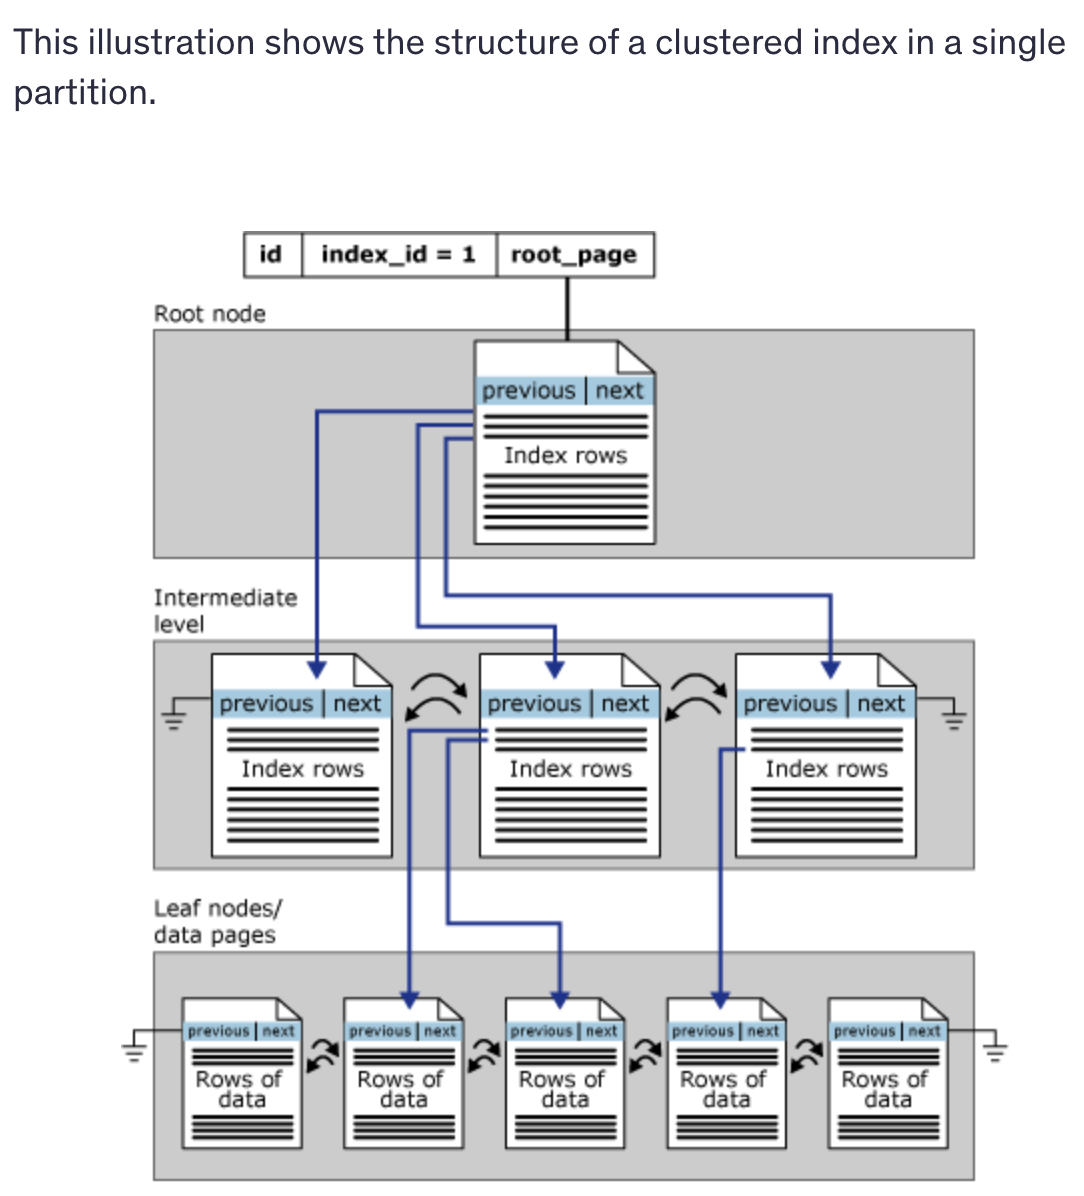
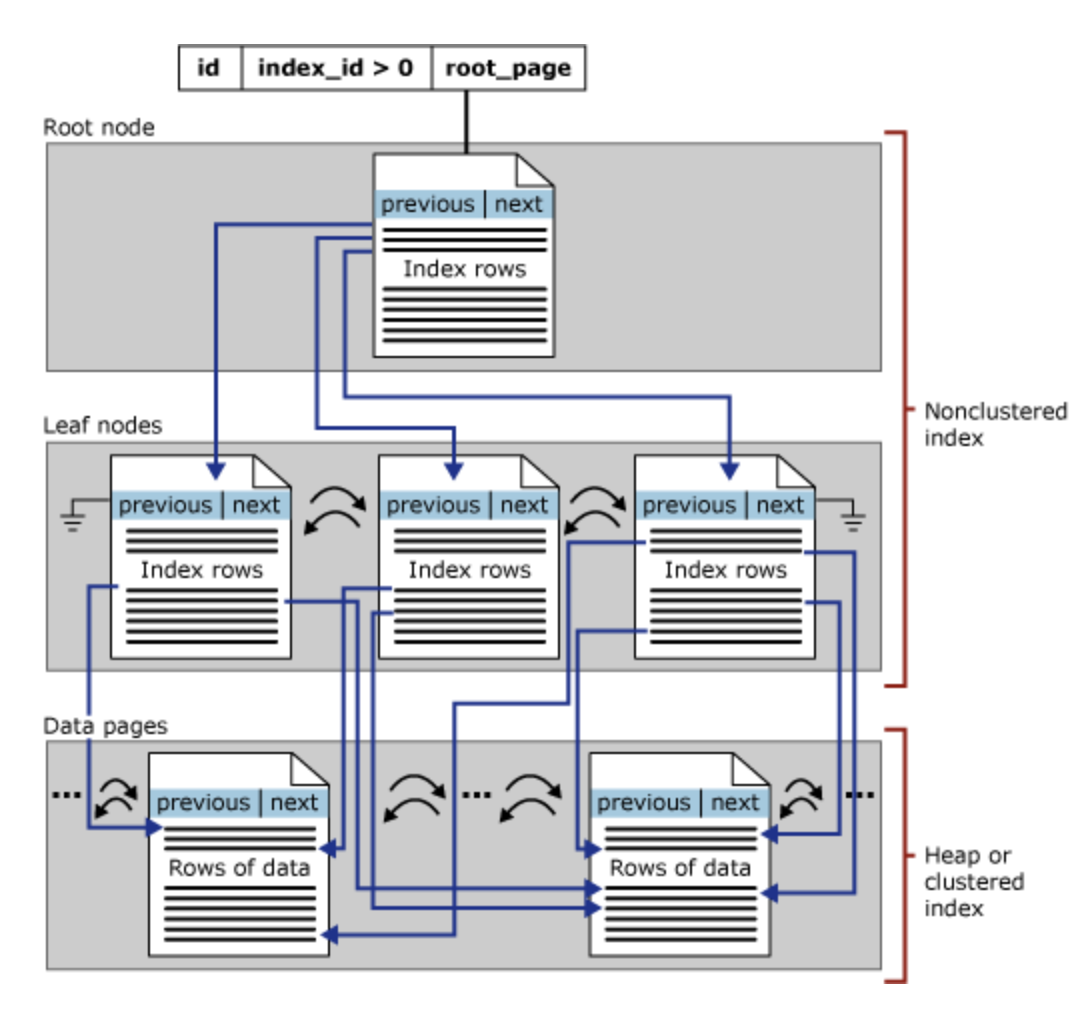


### 2.1 Seek vs Scan

In [ ]:
Seek: Like using an index in a book to jump directly to the topic you want.
Scan: Like reading the whole book from start to finish looking for a topic.

| Operator              | Works On           | Search Type  | Performance | Description
|-----------------------|--------------------|--------------|-------------|---------------------------------------------|
| Index Seek            | Non-clustered Index| Targeted     | ✅ Fast      | Looks up specific rows using index keys     | Query matches a Non-clustered Index
| Index Scan            | Non-clustered Index| Full Scan    | ❌ Slower    | Reads the entire non-clustered index        | It reads entire non-clustered Index, when Query needs a large portion of data.
| Clustered Index Seek  | Clustered Index    | Targeted     | ✅✅ Very Fast| Looks up rows directly in table by key      | Query matches a Clustered index
| Clustered Index Scan  | Clustered Index    | Full Table   | ❌❌ Slow     | Reads the entire table (clustered index)    | When query touches most of rows, or no filters applied (like select all rows) or filter applied on non-index fields.




### 2.1.1 Types of Scan

In [ ]:
# Types of Scan
1. Sequential Table Scan
    - A full scan of the entire table, reading every row regardless of filters or indexes.
    🔸 When it’s used:
    	•	No index exists on the filter column
    	•	The query needs most or all rows
    	•	The table is small (faster than using an index)
    🔸 Performance:
        - Slow for large tables
        - Fast for small tables or queries without filters
    🔸 Working
        FOR each page in table:
            FOR each row:
                check filter condition

2. Index Scan
    - A sequential scan of an index structure (typically a B-tree) to find matching rows.
    - but still needs to fetch the full row data from the table (heap or clustered index) for some columns.
            - Because the query has select columns, where the index does not contain all the columns required by the query.
        	- DB needs to do a “lookup” to fetch missing columns.

    🔸 When it’s used:
        •	Index exists on the filtered column
        •	The index covers a large range or returns many rows
        •	The optimizer finds it cheaper than random lookups (seek)
    🔸 Performance:
        -  Faster than table scan if filter matches many rows
        -  Slower than Index Only Scan due to extra row fetch (from table page)

3. Index Only Scan
    - The database satisfies the entire query from the index itself, with no need to read table rows. (it includes where and joins, select columns)
    - Cost: Best possible scan, as no extra I/O to fetch table rows.
    - Achieved using "Include()"
    - Example: CREATE INDEX IX_Users_Email_Includes
                    ON Users(Email)
                    INCLUDE (Name, LastLogin);
  

4. Bitmap Index Scan (in PostgreSQL, Oracle)
    - Uses a bitmap to represent matching rows across multiple index scans, combining them efficiently.
    🔸 When it’s used:
    	•	Multiple indexes on different columns are involved
    	•	Queries with multiple AND/OR conditions
    🔸 Performance:
        -  Efficient for combining multiple filters
    	- Reduces I/O by batching row fetches
    🔸 Working:
        - Query: SELECT * FROM Sales WHERE Region = 'East AND ProductCategory = 'Electronics';
            - Bitmap index scan: combines bitmap from index on Region and ProductCategory
            - It has a bit (1/0) bitmap, it first filter based on Region and then on ProductCategory and then take Intersection of both.


=> Sequential Scan:
[Page 1] --> [Page 2] --> [Page 3] --> ... check all rows

=> Index Scan (B-tree):
       [Root]
         |
     +---+---+
     |       |
 [100]     [300]
  |          |
[110]      [320]
Fetch rows based on index keys

=> Bitmap Index Scan:
[Index A] → Bitmap A: 1 0 1 0 1
[Index B] → Bitmap B: 0 1 1 0 0
Combined → Bitmap C (AND/OR)
          → 0 0 1 0 0 → fetch row 3            

In [ ]:
# FAQ
1. If table is small, then regardless of index, DB use sequentail scan.
    - Loading Index and B-tree building will take more time, so it does a direct sequentail scan.

2. Secnario: We inserted just 10 rows in table and start querying the table, and then we inserted 1M rows and imediately start querying on the index column.
    - Result will be so slow, as DB is doing sequentail scan as the DB statistics are not updated yet.
    - So, DB thinks there are a few rows only, so better to do a sequentail scan.
    - and If we query statistics, we can see those stats are not updated yet.

3. Why DB reads a page from disk, not directly a row.
    - Page size is fixed, and row size are not fixed as in a row some values might have null and small data.
    - In harddrive, we have to fetch a page/block. There is no concept of fetching a bit out of disk.
    - In RAM, we have byte address, so that is different.

4. In a Un-clustered query.
    - from the B-tree leaf node, which has the page address and the row id.
    - so, it loads the page into memory and scan the rowId in that page, as it is unordered in one page.

5. Indexing a gender column (that value has male/female)
    - If we have 1M rows, then 50% will have male and rest will have female., just indexing on this column is useless. As still we have to do a sequentail scan on 0.5M rows.

6. What happens to index, when we update or insert a new row.
When you UPDATE a row:
	•	If you change a column that is part of an index, the database updates that index’s structure (B-Tree, Hash, etc.) to reflect the new value.
	•	If the column is not part of an index, the index doesn’t need to be touched for that column — but the clustered index (or heap row storage) still gets updated because it stores the actual row.

7. When you create an index,
    - Concurrently, In parallel, you can only read that table, no update or insert are allowed. As it acquires a special kind of lock of table.
    - In postgress, there is something called Create Index Concurrently, which allows update/edit/insert while creating the index.
        - But it is 2 times slower than the normal.
        - How it works, It first create a normal index, then it check if someone has made changes, if yes then it will apply those changes.

### 2.2 Index Working (Ordering)

In [ ]:
Index works left to right, meaning the prefix order matters
    - Composite indexes only efficiently support queries that start with the left-most column(s) of the index.
    - 
        
        
# Example 1
    CREATE INDEX IX_MyTable_ABC ON MyTable (A, B, C);

# Index sorted like this: 
Index (A, B, C)
├── A1
│   ├── B1
│   │   ├── C1 → Row
│   │   ├── C2 → Row
│   ├── B2
│       ├── C3 → Row
├── A2
    ├── B1
        ├── C4 → Row


Case 1. index used, if query has filter on
     - A only
     - A, B only
     - A, B, C

Case 2: Index non-used, if query has filter on
    - B only
    - B, C
    - C

Case 3: Partial seek, if query has filter on
    - A and C

Case 4: Filter on A OR B
    - Full table scan, it won't use the index



# Example 2
Create individual index on A and B.
    CREATE INDEX IX_A ON MyTable (A);
    CREATE INDEX IX_B ON MyTable (B);

Case 1: Query filters on A, B, C
    - SQL uses something called Index Intersection. SQL Server can combine multiple indexes using bitmap intersection or merge (called index intersection).
        - Seek IX_A → get list of matching Row IDs (RIDs)
        - Seek IX_B → get list of matching RIDs
    	- Intersect both RID lists
        - Then, scan for C column 

Case 2: Query filters on A OR B
        - Seek IX_A → get list of matching Row IDs (RIDs)
        - Seek IX_B → get list of matching RIDs
    	- Union both RID lists

Case 3: filter Query A in (10, 20, 30)
    - Seek on IX_A multiple times for each value

Case 4: Filter query with range as well
    -  Query: A=10 and B > 10
    - Most likely: Seek on IX_A, then apply B > 100 as a residual filter (most likely)
    - Less likely: Intersect IX_A and IX_B 



        +----------------------------+
        |  Query with filters A, B  | (Case 1)
        +----------------------------+
                   |
                   v
    +------------------------------------------+
    | Is there a composite index (A,B)?        |
    | ➜ YES: Use that index (seek)             |
    | ➜ NO: Check for index intersection       |
    +------------------------------------------+
                   |
                   v
    +----------------------------------------------+
    | Can IX_A and IX_B be intersected efficiently?|
    | ➜ YES: Intersect, then Lookup + Filter C     |
    | ➜ NO: Pick most selective single index (A or B)|
    +----------------------------------------------+
                   |
                   v
    +-------------------------------+
    |  Apply remaining filters (C) |
    +-------------------------------+

# Example 3
- Two seperate index (A, B) and (B)
    CREATE INDEX IX_A_B ON MyTable (A, B);
    CREATE INDEX IX_B ON MyTable (B);

Case 1: It will use the index for 
    - Query on A only (IX_A_B)
    - Query on B only (IX_B)
    - Query on A and B (IX_A_B)
    - Query on A OR b (IX_A_B, IX_B)
                             

# Example 4
- Table has a index on column A,
Case 1: It will use the index for
    - SELECT COUNT(A) FROM T WHERE A BETWEEN (10, 50);
    - SELECT MAX (A) FROM T;
    - SELECT MIN (A) FROM T;

Case 2: It will not use the index for
    - SELECT COUNT(A) FROM T;





In [ ]:
# Conditional index
A Conditional Index is an index that is created only on a subset of rows that meet a specified condition (using a WHERE clause)
Pros:
    - Smaller index size, so faster Inserts/ Updates
    - Better read performance
    - Ideal for columns with multiple Null or soft deletes
Example
    - CREATE NONCLUSTERED INDEX IX_Orders_PendingStatus
        ON Orders(Status)
        WHERE Status = 'Pending';
    - this will create index for rows, where Status = ‘Pending’.

In [ ]:
# Rules of Creating Composite index (ordering)
1. Highly selective equality filter: like UserId that narrow down to few rows
2. Additional equality filters: "AND Type=?"
3. Range Filters: "AND CreatedDate > ?" , this works only if previous are satisfied.
4. Order by/ Group by columns: "Order by CreatedDate", this will avoid sorting if index is already ordered.

In [ ]:
# Statistics
- Database use table statistics to plan, which indexes should be used for a query or it should do a full table scan.

# Creating concurrently index 
    - usually used in production to create index on column with large table.
    - It does not block the table, and create the index in parallel
    - Query: Create Index concurrently g on grades(g);

# Bloom filters
  - A Bloom Filter is a probabilistic data structure used to test whether an element is a member of a set
  - It may return 
        - Positive: required user may exist
        - Negative: required user does not exist

Bit array (size m):

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   ← initial

Insert "apple":
  hash1("apple") = 3
  hash2("apple") = 7
  → set bit[3] and bit[7] to 1

[0, 0, 0, 1, 0, 0, 0, 1, 0, 0]

Check "banana":
  hash1("banana") = 2 → bit[2] = 0
  → "banana" definitely NOT in set

Check "apple":
  bit[3] = 1 and bit[7] = 1 → "apple" might be in set

In [ ]:
# How to work with billion rows
Approach 1: Brute Force (if there is no index)
    - Do multi-threading or multi-processing and search the table in parallel. (kind of how big data works)

Approach 2: Can we avoid scaning the complete table
    - Create index if possible

Approach 3: Partitioning (Horizontal Partitioning)
    - Requires a Parition key
    - It is like split a complete table into multiple tables and based on the partition key, we will know which table to search for.
    - Here, we might search one or multiple tables for just one key.

Approach 4: Partitioning and Sharding
    - spliting a table into multiple tables and each table is in a seperate database on multiple host.

In [ ]:
# INCLUDEDED Columns
 - In a non-clustered index, you can add extra columns to the index just for reading, without adding them to the actual index key (i.e., sort order).
 - Doesn’t affect index tree as Included columns are stored at leaf level only, not in sorted B-tree
 - Usecase: To make Index covering for a query
    - All the columns in the SELECT clause
	- All columns in WHERE, JOIN, ORDER BY, etc. are available in the index itself, so SQL Server doesn’t need to go back to the main table (called a bookmark/lookup/key lookup).
 - Things to avoid
   - Including columns with large text, it bloats index                                                                                                                                                 

CREATE NONCLUSTERED INDEX IX_YourIndex
    ON YourTable (KeyColumn1, KeyColumn2)
    INCLUDE (IncludedColumn1, IncludedColumn2);

In [ ]:
# Key Terms
Residual predicate: It is a filter that SQL Server applies after the index seek, because the index itself can’t fully satisfy the query.

# Key vs Non-Key Index
1. Key index (also called unique index/ primary index)
    - Created on a Primary Key or Unique constraint.
	- Ensures uniqueness of values in the column(s).
	- Often clustered by default in many RDBMSs (e.g., SQL Server).

2, Non-Key Index (also called: Non-Unique Index):
	- Created on non-key columns to improve query performance.
	- Does not enforce uniqueness.
	- Can be clustered or non-clustered, depending on use.    

#     

### 2.3 Row vs Column Oriented Databases

In [ ]:
# Row Oriented Database (Row store)
- Tables are stored as rows in disk
- A single block io read to the table fetches multiple rows with all their columns.
- More IOs are required to find a particular row in a table scan, but once you find the row you get all columns for that row.
- Example: MySQL, Postgress, SQL server
- Best for
    - OLTP systems (Online Transaction Processing)
	- Fast INSERT/UPDATE/DELETE
	- Accessing complete rows frequently

Row 1 → [1, Alice, 30, India]
Row 2 → [2, Bob, 25, Canada]

- Case 1: 
    - Select X from table where Z=1
    - This will pull the page/ block (that might have multiple rows) in memeory, and once the condition satisfy it will return the select columns, as all the columns are already in memeory. No extra IO required.

- Case 2: 
    - Select * from table where Id=1
    - Same case, all columns are already in memeory, as we have pulled the complete block in memory which has all the columns in memeory for that particular row.

- Case 3:
    -  Select sum(salary) from emp
    - We have to pull all pages (that has all columns and all rows) in memory. But we just need salary.



# Column Oriented Database (Column store)
- data is stored column by column — all values of a column are stored together.
- Less IO are required to get more values of a given column. But working with multiple columns require more IO
- Example
    - Google big query
    - Apache Cassandra
- Best for     
    - OLAP systems (Online Analytical Processing)
	- Large-scale aggregations, scans, filters
	- Compresses better (same-type values in a column)   
- Worst for
    -  queries like select *
                               
Column ID     → [1, 2]
Column Name   → [Alice, Bob]
Column Age    → [30, 25]
Column Country→ [India, Canada]
                               

| Feature             | Row-Oriented DB                 | Column-Oriented DB               |
|---------------------|----------------------------------|----------------------------------|
| Storage Format      | Row-by-row                       | Column-by-column                 |
| Best Use Case       | OLTP                             | OLAP                             |
| Write Speed         | Fast for single row              | Slower                           |
| Read Speed (All Cols)| Fast                             | Slower                           |
| Read Speed (Few Cols)| Slower                          | Very fast                        |
| Compression         | Less efficient                   | Very efficient                   |
| Joins               | Generally better                 | Needs optimization               |
| Example DBs         | PostgreSQL, MySQL, SQL Server    | Redshift, BigQuery, ClickHouse   |                               

# 3. SQL query execution order

In [ ]:
# Order
1. FROM
    - Engine starts by access the base table first

2. ON
    - If query has Joins, then Join conditions are evaluated.
    - Example: ON e.DeptId = d.Id will match rows between Employees and Departments.

3. JOIN
    - Performs the actual join operation (Nested Loop, Hash Join, etc.).
	- This creates a combined row set.

4. WHERE
    - Filters rows after joins but before grouping

5. GROUP BY
    - All aggregate functions (COUNT, AVG, etc.) are calculated per group here.

6. HAVING
    - Filter the aggregated result. Like HAVING COUNT(*) > 1 to remove small groups.

7. SELECT
    - Chooses which columns or expressions to return.

8. DISTINCT
    - Removes duplicate rows from the final result.
    - Example: SELECT DISTINCT Country FROM Customers;

9. ORDER BY
    - You can only ORDER BY columns available in SELECT.

10. TOP / OFFSET
    - Limits the result set to N rows or pages.

# Example:
    SELECT TOP 5 d.Name, COUNT(e.Id) AS EmployeeCount
    FROM Departments d
    JOIN Employees e ON e.DeptId = d.Id
    WHERE e.Salary > 50000
    GROUP BY d.Name
    HAVING COUNT(e.Id) > 3
    ORDER BY EmployeeCount DESC

Step    Clause               Description
-----   ------------------   --------------------------------------------
1       FROM Departments     → Get base table 'Departments'
2       JOIN Employees ON    → Join with 'Employees where DeptId matches
3       WHERE e.Salary > 50k → Filter out low-salary employees
4       GROUP BY d.Name      → Group the remaining by department name
5       HAVING COUNT > 3     → Keep groups with more than 3 employees
6       SELECT ...           → Pick columns: d.Name and count
7       ORDER BY             → Sort by EmployeeCount
8       TOP 5                → Pick only top 5 rows

# 4. B Tree vs B+ Tree in Production System

In [ ]:
Both are balanced tree data structures used to store sorted data and allow efficient search, insert, delete, and range queries.
They are designed to minimize disk I/O, which is crucial for database indexes.

# B-Tree
    - B-Tree has Nodes
    - In B-Tree of "m" degree, nodes can have m child nodes.
    - A Node has up to (m-1) elements.
    - the value of m, is decided by DB only
    - Element: each element has a key and a value.
    - A node = disk page
    - The value is usually a data pointer to the row and can point to primary key (like secondary index in my sql) or tuple (like postgress point to tuple directly).
	- Each node contains keys + child pointers + (optionally) data pointers
	- All keys are stored in internal and leaf nodes
	- Tree is kept balanced (i.e., same height for all leaves)
    - Example: Not used in DB


# Table
TID  ID  Name
701  1 AAA
702  2 AAB
703  3 AAC
704  4 AAD
705  5 AAE

- TID: Table internal tuple/ Id/ page id
- Element: 2:702
    - Key is 2 (what we search for)
    - Value: is 702, data pointers (reference to page id)

# B-Tree representation
     2:702    4:704
     /      |      \
1:701    3:703     5:705

# Limitation of B-Tree
1. Elements in all nodes store both the key and value
2. so, Internal nodes take more space, means one page will have less data, then we need to load more pages from disk, than means more IO operation, then it becomes slow.
3. Range queries are slow because of random access (give me all value 1-5). It like accessing the tree node by node.


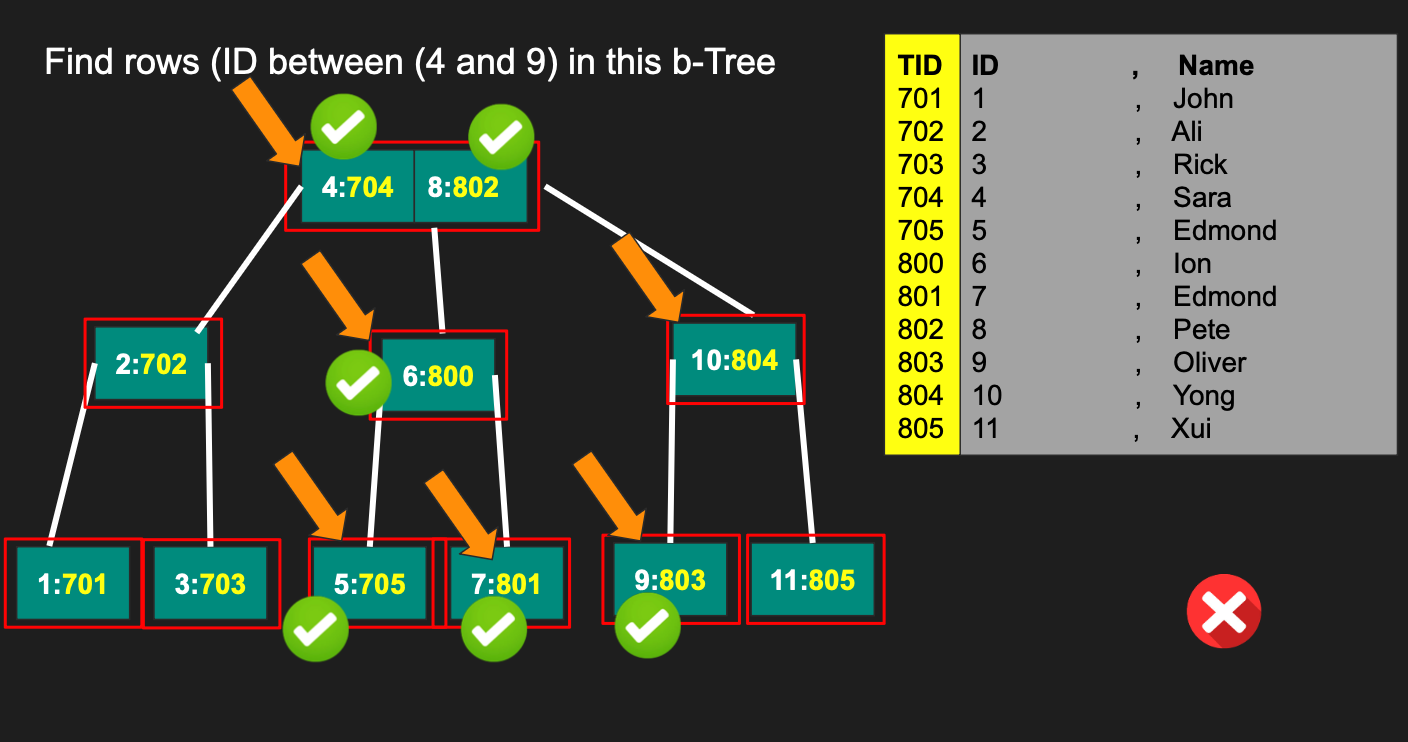

In [ ]:
# B+ Trees
 - It stores keys in internal nodes
 - Values are stored in leaf nodes only.
 - Internal nodes are smaller since they only store keys and they can fit more elements.
 - Leaf nodes are linked, so once you find a key, you can find all values before and after that key - best for range queries.
 - Used in RDBMS, SQL server, MySQL
 - leaf nodes: will have all the nodes and will have data pointers at leaf node only
 - Linked leaves
 - Search time O(log n)
 - Internal nodes of index are smaller in size and can easily fit in memory, faster access/ search operation.
 - Storage
    - B+Tree secondary index values can either point direct to the tuple (postgress) or to the primary key (mySQL)
    - If the primary key data type is expensive this can cause bloat in all secondary indexes for databases such as MySQL (like GUID and long string)
    -                                                                                               
- A tree of degree 3
    - Max keys per node: degree -1 => 2
    - Max children per node: 3
    

                         5
             ________________________
            /                        \
           3.                        7|9
       __________                 __________
      /          \                /   |     \
    2             4              6    8     10
   /  \.        /    \         /   \
1:701->2:702->3:703-> 4:704  5:705->6:706

Document number: 7
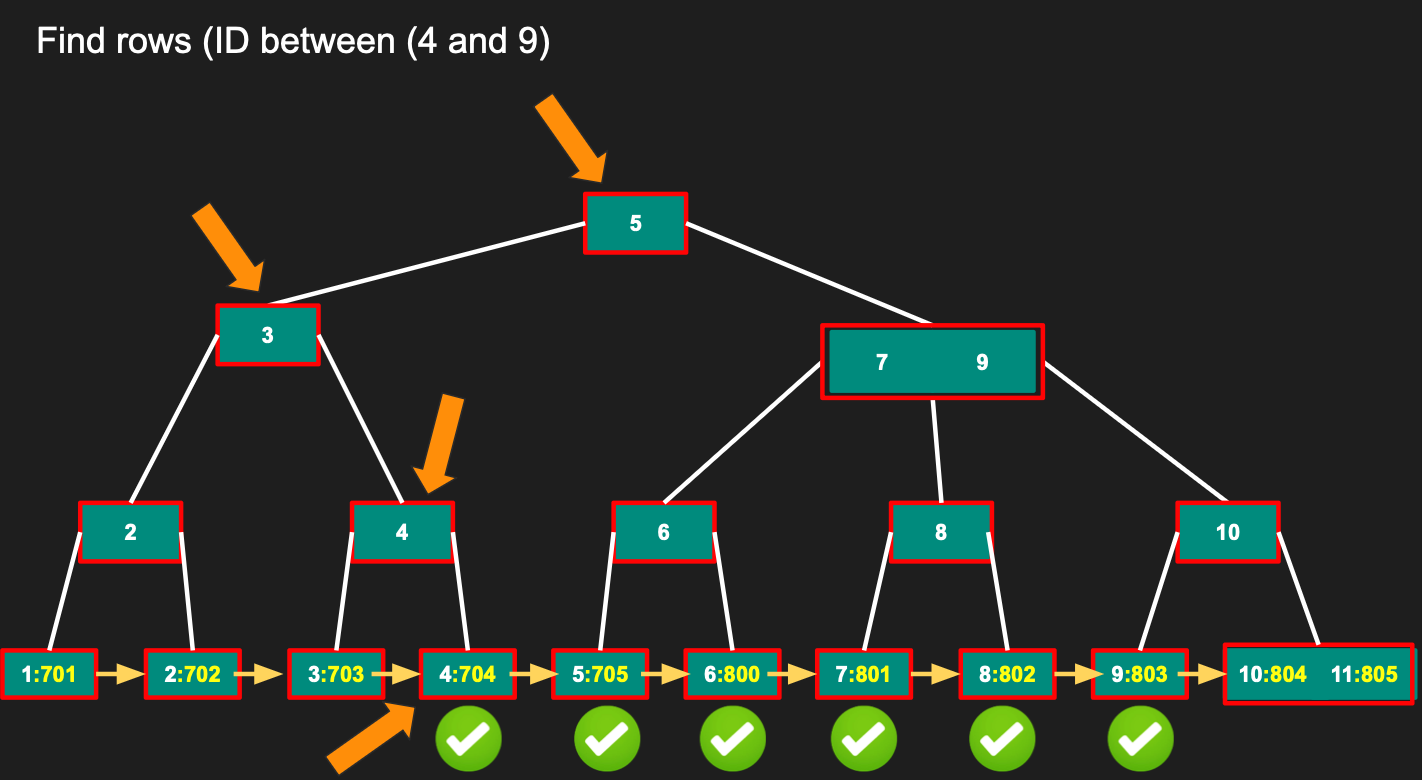


# 5. Improving Efficiency

In [ ]:
1. How a Write Works with an Indexed Column

When you insert or update a row in a table that has an index on the UUID column/ or any other column, the DB must:
	1.	Insert the row into the table’s data pages
    	•	If the UUID is the primary key in a clustered index (e.g., in SQL Server, MySQL InnoDB), the table itself is physically organized as a B-tree by that UUID.
    	•	If it’s a secondary index, the index is a separate B-tree, but still sorted by UUID.
	2.	Find the correct position in the index
    	•	The database searches the B-tree to find where this UUID should go to maintain sorted order.
	3.	Insert the index entry
    	•	If the right page is full, the DB must perform a page split:
    	•	Allocate a new page
    	•	Move about half of the rows from the old page to the new page
    	•	Update parent nodes in the B-tree
    	•	Page splits cause fragmentation → scattered disk/memory layout → slower reads.

In [ ]:
# SQL Index Efficiency column type selection

+--------------------------+-------------------+-------------------+---------------------------+------------------------------+
| Index Key Type           | Insert Performance| Read Performance  | Fragmentation Risk        | Typical Use Case             |
+--------------------------+-------------------+-------------------+---------------------------+------------------------------+
| Sequential INT (PK)      | Excellent (fast)  | Excellent (fast)  | Very Low                  | Auto-increment PK, log table |
| Sequential BIGINT (PK)   | Excellent (fast)  | Excellent (fast)  | Very Low                  | Large-scale PKs              |
| Random UUID v4 (PK)      | Poor (slow)       | Good (OK reads)   | Very High (frequent splits)| Distributed IDs, uniqueness  |
| UUID v4 (Secondary Index)| Poor (slow)       | Good              | High                      | Searching by UUID key        |
| ULID / UUID v7 (time-sort)| Good              | Excellent         | Low to Medium             | Globally unique + ordered    |
| Natural Key (short text) | Medium            | Good              | Low to Medium             | Lookup by code, SKU, email   |
| Long Text Key             | Poor              | Poor to Medium    | Medium                    | Rare; avoid as PK            |
| Composite Key (ordered)  | Medium to Poor    | Good (with filter)| Medium                    | Multi-column uniqueness      |
| Non-clustered Index (INT)| Good              | Excellent         | Low                       | Frequent filtering/sorting   |
| Non-clustered Index (UUID)| Poor              | Good              | High                      | Secondary UUID lookups       |
+--------------------------+-------------------+-------------------+---------------------------+------------------------------+
Legend:
- Insert Performance: speed of adding rows when index is maintained
- Read Performance: speed of queries that use this index
- Fragmentation Risk: how quickly index pages become disorganized

In [ ]:
# Choosing Index column (UUID vs ULID)
1. UUID v4
	•	Universally Unique Identifier, version 4
	•	128-bit value (typically shown as 36 characters with hyphens)
	•	Randomly generated → no natural ordering
    •	Why UUID v4 Hurts Writes
    	•	UUID v4 is random.
    	•	Random values → inserts go all over the B-tree.
        •	Random UUIDs → touch random pages → frequent page splits.
    	•	This means:
        	•	Constant page splits, because inserts don’t append to the end
        	•	Poor cache locality (the DB can’t predict where the next write will go)
        	•	More I/O because multiple random pages are touched per insert

Problem: Instead of sequential appends, you’re constantly jumping between pages, forcing them to be re-balanced. So, Write operation becomes exponantially slow, reads operation are still fast.
    •	Page splits
	•	Fragmentation
	•	Poor cache locality

Even if UUID is not your primary key:
	•	Secondary indexes still have the same problem — random inserts cause page splits in that index.
	•	The table’s data pages might still be fine if the clustered index is sequential, but the UUID index will still be fragmented.  

# New Version Improvement
    - UUID v7 (time-ordered UUID spec from 2022).                                                                                       
                                                                                       
2. Sequentail IDs (Int/ ULID)
    •	Sequential IDs (auto-increment, timestamp-based) → inserts always go to the end of the B-tree, only touching the last page → no page splits until a page fills.  

3. ULID (Universally Unique Lexicographically Sortable Identifier)
	•	128-bit value, but first 48 bits = timestamp, rest are random.
	•	Lexicographically sortable — newer IDs are greater than older IDs.
    •	Impact on SQL Indexes
    	•	Inserts are mostly sequential (time-based), so:
    	•	Minimal page splits
    	•	Less fragmentation
    	•	Better cache efficiency
    •	Still globally unique, but ordered by creation time.                                                                                       